# Entrega 3 — Validação dos modelos de árvore contra dados nunca vistos
## CRISP-DM: Avaliação · generalização em `validation/*.json`

Este notebook mede a **generalização** dos 4 modelos de árvore treinados no notebook
`05_execucao_doe_arvores_entrega3.ipynb` (EXP-02, EXP-03, EXP-05, EXP-06) sobre
**dados nunca vistos** — arquivos JSON no formato OpenFDA em `validation/`.

**Princípio inegociável — zero vazamento:** nada é ajustado na validação. Scaler,
imputador KNN, *One-Hot*, TF-IDF e os modelos vêm **todos do treino**. A coluna
`serious` da validação é **só gabarito** de avaliação.

**Pipeline reproduzido (com parâmetros do treino):**
1. Reproduz o `01_data_preparation` sobre `validation/*.json` (streaming com `ijson`).
2. Reproduz o `02_entrega2_transformacao` aplicando parâmetros do treino (faixa etária,
   imputação KNN re-ajustada **só no treino**, *feature engineering*, padronização com o
   scaler salvo).
3. Carrega os Pipelines `outputs/models/*.joblib` e calcula **as mesmas métricas** do
   nb05 (função `avaliar`), guardando os **hiperparâmetros** de cada modelo.

> **Observação:** os modelos foram treinados em `MODO_RAPIDO = True` (espaço de busca
> reduzido). As métricas de validação são comparáveis às de teste do nb05, mas não são
> os resultados oficiais da Tabela 1 do PDF.


## 0. Configuração e imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import ijson
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Resolução robusta de caminhos (notebook executado de notebooks/ ou da raiz).
_root = Path.cwd()
if (_root / "outputs").exists():
    OUTPUTS_DIR = _root / "outputs"
elif (_root.parent / "outputs").exists():
    OUTPUTS_DIR = _root.parent / "outputs"
else:
    OUTPUTS_DIR = _root / "outputs"
PROJ = OUTPUTS_DIR.parent
VALID_DIR = PROJ / "validation"
MODELS_DIR = OUTPUTS_DIR / "models"

val_json_files = sorted(VALID_DIR.glob("*.json"))
print("OUTPUTS_DIR :", OUTPUTS_DIR)
print("VALID_DIR   :", VALID_DIR)
print("Arquivos de validação:", [p.name for p in val_json_files])
print("Modelos .joblib       :", [p.name for p in sorted(MODELS_DIR.glob("*.joblib"))])

OUTPUTS_DIR : /home/jovi/src2/datamining-project-unifei/outputs
VALID_DIR   : /home/jovi/src2/datamining-project-unifei/validation
Arquivos de validação: ['drug-event-0007-of-0034.json', 'drug-event-0014-of-0034.json']
Modelos .joblib       : ['EXP-02_random_forest.joblib', 'EXP-03_gradient_boosting.joblib', 'EXP-05_random_forest.joblib', 'EXP-06_gradient_boosting.joblib']


In [2]:
# Constantes e convenção de métricas IDÊNTICAS ao nb05 (comparabilidade exige replicar).
TARGET = "serious"
ID_COLS = ["Unnamed: 0", "safetyreportid"]

FEATURES_ENGENHARIA = ["feature_n_active_substances", "feature_n_drug_types",
                       "feature_has_medicinal_product", "feature_multiple_drugs",
                       "feature_is_usa"]
FLAG_IMPUTACAO = "patient.ageGroupCalculated_was_imputed"
CONJUNTO_A = ["occurcountry", "patient.patientsex", "patient.ageGroupCalculated",
              "patient.drug.count",
              "patient.drug.activesubstance.activesubstancename",
              "patient.drug.medicinalproduct"]
CONJUNTO_B = CONJUNTO_A + FEATURES_ENGENHARIA + [FLAG_IMPUTACAO]
feature_sets = {
    "A_baseline": {"rotulo": "Baseline (11)", "colunas": CONJUNTO_A},
    "B_completo": {"rotulo": "Completo (17)", "colunas": CONJUNTO_B},
}

def conj_key(conjunto):
    return "A_baseline" if "Baseline" in str(conjunto) else "B_completo"


def avaliar(estimator, X, y, conjunto):
    """Mesma convenção do nb05: rótulos (predict) para acc/precision/recall/f1/CM;
    probabilidade (predict_proba[:,1]) para ROC AUC."""
    y_pred = estimator.predict(X)                  # saída CATEGÓRICA (rótulos)
    y_proba = estimator.predict_proba(X)[:, 1]     # saída CONTÍNUA (probabilidade)
    return {
        "conjunto": conjunto,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_pos": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "precision_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y, y_proba),
    }

print("Config pronta. Conjuntos:", list(feature_sets))

Config pronta. Conjuntos: ['A_baseline', 'B_completo']


## 1. Reproduzir o `01_data_preparation` sobre a validação (streaming)

Os JSON são lidos **registro a registro** com `ijson` (memória limitada). Por registro
extraímos os campos base e a lista `patient.drug[]`, normalizamos o texto (strip +
maiúsculas) e agregamos os medicamentos do registro com a mesma lógica do nb01
(`join_unique_values`, `count = nº de medicamentos`). Depois: descarta `occurcountry`
nulo, mapeia o sexo e descarta registros **sem `serious`** (sem gabarito não há como
avaliar).

In [3]:
def normalize_text_value(value):
    if value is None:
        return np.nan
    value = str(value).strip()
    if not value:
        return np.nan
    return value.upper()


def join_unique_values(values):
    vals = [str(v).strip() for v in values if v is not None and str(v).strip() != ""]
    uniq = sorted(set(vals))
    return " | ".join(uniq) if uniq else np.nan


def stream_records(path):
    with open(path, "rb") as f:
        for rec in ijson.items(f, "results.item"):
            yield rec


linhas = []
for path in val_json_files:
    n = 0
    for rec in stream_records(path):
        patient = rec.get("patient") or {}
        drugs = patient.get("drug") or []
        if isinstance(drugs, dict):
            drugs = [drugs]
        active = join_unique_values(
            normalize_text_value((d.get("activesubstance") or {}).get("activesubstancename"))
            for d in drugs)
        medic = join_unique_values(
            normalize_text_value(d.get("medicinalproduct")) for d in drugs)
        drugchar = join_unique_values(
            (None if d.get("drugcharacterization") is None
             else str(d.get("drugcharacterization")).strip()) for d in drugs)
        sid = rec.get("safetyreportid")
        linhas.append({
            "safetyreportid": str(sid) if sid is not None else np.nan,
            "serious": rec.get("serious"),
            "occurcountry": rec.get("occurcountry"),
            "patient.patientsex": patient.get("patientsex"),
            "patient.patientonsetage": patient.get("patientonsetage"),
            "patient.patientonsetageunit": patient.get("patientonsetageunit"),
            "patient.drug.activesubstance.activesubstancename": active,
            "patient.drug.drugcharacterization": drugchar,
            "patient.drug.medicinalproduct": medic,
            "patient.drug.count": len(drugs),
        })
        n += 1
    print(f"{path.name}: {n} registros lidos")

val_clean = pd.DataFrame(linhas)
print("Bruto (todos os registros):", val_clean.shape)

drug-event-0007-of-0034.json: 12000 registros lidos


drug-event-0014-of-0034.json: 12000 registros lidos
Bruto (todos os registros): (24000, 10)


In [4]:
# Limpeza equivalente ao nb01
drug_text_cols = ["patient.drug.activesubstance.activesubstancename",
                  "patient.drug.drugcharacterization",
                  "patient.drug.medicinalproduct"]
val_clean[drug_text_cols] = val_clean[drug_text_cols].fillna("unknown")
val_clean["patient.drug.count"] = val_clean["patient.drug.count"].fillna(0).astype(int)

n0 = len(val_clean)
val_clean = val_clean.dropna(subset=["occurcountry"]).copy()
n1 = len(val_clean)

sex_map = {"1": "male", "2": "female", "0": "unknown"}
val_clean["patient.patientsex"] = (val_clean["patient.patientsex"].astype("string")
                                   .str.strip().map(sex_map).fillna("unknown"))

val_clean = val_clean.dropna(subset=["serious"]).copy()
n2 = len(val_clean)

print(f"Após dropna(occurcountry): {n0} -> {n1}  (removidos {n0 - n1})")
print(f"Após dropna(serious)     : {n1} -> {n2}  (removidos {n1 - n2})")

dest_cleaned = OUTPUTS_DIR / "drug_events_validation_cleaned.csv"
val_clean.to_csv(dest_cleaned, index=False)
print("Salvo:", dest_cleaned, "| shape:", val_clean.shape)
print("Distribuição de serious:")
print(val_clean["serious"].astype(int).value_counts(normalize=True).sort_index().round(4))

Após dropna(occurcountry): 24000 -> 22001  (removidos 1999)
Após dropna(serious)     : 22001 -> 21899  (removidos 102)
Salvo: /home/jovi/src2/datamining-project-unifei/outputs/drug_events_validation_cleaned.csv | shape: (21899, 10)
Distribuição de serious:
serious
1    0.5581
2    0.4419
Name: proportion, dtype: float64


## 2. Reproduzir o `02_entrega2_transformacao` com parâmetros do treino

- **Faixa etária**: recriada deterministicamente de `patientonsetage`/`unit`.
- **Imputação KNN**: o `Pipeline(ColumnTransformer + KNeighborsClassifier)` é
  **re-ajustado nos registros conhecidos do conjunto de TREINO** (a partir de
  `drug_events_cleaned.csv`, mesmo split 70/30 estratificado, `random_state=42`) — fit
  determinístico, equivalente ao do nb02 — e aplicado aos `unknown` da validação. Sem
  vazamento (fit só usa treino).
- **Feature engineering**: 5 features determinísticas.
- **Padronização**: scaler do treino (mean/scale de `data_preparation_metadata.json`),
  **sem refit**.

In [5]:
def age_to_years(age, unit):
    if age is None or unit is None:
        return np.nan
    try:
        age = float(age)
    except (TypeError, ValueError):
        return np.nan
    try:
        unit_code = int(float(unit))
    except (TypeError, ValueError):
        return np.nan
    if unit_code == 800:
        return age * 10
    if unit_code == 801:
        return age
    if unit_code == 802:
        return age / 12
    if unit_code == 803:
        return age / 52
    if unit_code == 804:
        return age / 365
    if unit_code == 805:
        return age / (365 * 24)
    return np.nan


def calculate_age_group(age_years):
    if pd.isna(age_years):
        return "unknown"
    if 0 <= age_years < 2:
        return "baby_early_childhood"
    if 2 <= age_years < 12:
        return "child"
    if 12 <= age_years < 18:
        return "adolescent"
    if 18 <= age_years < 30:
        return "young_adult"
    if 30 <= age_years < 60:
        return "adult"
    if age_years >= 60:
        return "elderly"
    return "unknown"


def recompute_age_group(df):
    ay = df.apply(lambda r: age_to_years(r["patient.patientonsetage"],
                                         r["patient.patientonsetageunit"]), axis=1)
    ay = ay.mask((ay < 0) | (ay > 120))
    return ay.apply(calculate_age_group)


knn_features = ["occurcountry", "patient.patientsex",
                "patient.drug.drugcharacterization",
                "patient.drug.activesubstance.activesubstancename",
                "patient.drug.medicinalproduct", "patient.drug.count"]

# --- Re-ajustar o imputador KNN SÓ no treino (reproduzindo o split do nb02) ---
cleaned = pd.read_csv(OUTPUTS_DIR / "drug_events_cleaned.csv")
for c in drug_text_cols:
    cleaned[c] = cleaned[c].fillna("unknown").astype(str)
cleaned["patient.ageGroupCalculated"] = recompute_age_group(cleaned)

df_train_c, _ = train_test_split(cleaned, test_size=0.30, random_state=RANDOM_STATE,
                                 stratify=cleaned["serious"])
train_known = df_train_c[df_train_c["patient.ageGroupCalculated"] != "unknown"]

knn_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     ["occurcountry", "patient.patientsex", "patient.drug.drugcharacterization"]),
    ("active_substance", CountVectorizer(max_features=100, token_pattern=r"\b[\w-]+\b"),
     "patient.drug.activesubstance.activesubstancename"),
    ("medicinal_product", CountVectorizer(max_features=100, token_pattern=r"\b[\w-]+\b"),
     "patient.drug.medicinalproduct"),
    ("num", StandardScaler(), ["patient.drug.count"]),
])
knn_imputer = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance",
                                 algorithm="brute", metric="euclidean")),
])
knn_imputer.fit(train_known[knn_features], train_known["patient.ageGroupCalculated"])
print(f"KNN re-ajustado em {len(train_known)} registros conhecidos do treino "
      f"(de {len(df_train_c)} do split de treino).")

KNN re-ajustado em 13671 registros conhecidos do treino (de 22616 do split de treino).


In [6]:
# --- Aplicar transformações do nb02 à VALIDAÇÃO ---
val = val_clean.copy()
val["patient.ageGroupCalculated"] = recompute_age_group(val)
val[FLAG_IMPUTACAO] = (val["patient.ageGroupCalculated"] == "unknown").astype(int)

unk = val["patient.ageGroupCalculated"] == "unknown"
if unk.any():
    val.loc[unk, "patient.ageGroupCalculated"] = knn_imputer.predict(
        val.loc[unk, knn_features])
print(f"Faixa etária imputada em {int(unk.sum())} registros da validação.")


def count_pipe_values(value):
    if pd.isna(value) or str(value).strip().lower() == "unknown":
        return 0
    return len([p for p in str(value).split("|") if p.strip()])


val["feature_n_active_substances"] = (
    val["patient.drug.activesubstance.activesubstancename"].apply(count_pipe_values))
val["feature_n_drug_types"] = (
    val["patient.drug.drugcharacterization"].apply(count_pipe_values))
val["feature_has_medicinal_product"] = (
    val["patient.drug.medicinalproduct"].str.lower().ne("unknown").astype(int))
val["feature_multiple_drugs"] = (val["patient.drug.count"] > 1).astype(int)
val["feature_is_usa"] = val["occurcountry"].str.upper().eq("US").astype(int)

# Padronização com o scaler do TREINO (sem refit)
meta = json.loads((OUTPUTS_DIR / "data_preparation_metadata.json").read_text())
sp = meta["scaler_parameters"]
for feat, mean, scale in zip(sp["features"], sp["mean"], sp["scale"]):
    val[feat] = (val[feat].astype(float) - mean) / scale
print("Padronização aplicada às colunas:", sp["features"])

# Dropar colunas de idade de origem; alvo para int
val = val.drop(columns=["patient.patientonsetage", "patient.patientonsetageunit"])
val["serious"] = val["serious"].astype(int)

# Reordenar para o MESMO esquema de drug_events_train_transformed.csv (sem o índice Unnamed: 0)
train_cols = pd.read_csv(OUTPUTS_DIR / "drug_events_train_transformed.csv",
                         nrows=0).columns.tolist()
ordered = [c for c in train_cols if c != "Unnamed: 0"]
faltando = [c for c in ordered if c not in val.columns]
assert not faltando, f"Colunas ausentes na validação: {faltando}"
val = val[ordered]

dest_val = OUTPUTS_DIR / "drug_events_validation_transformed.csv"
val.to_csv(dest_val, index=False)
print("Salvo:", dest_val, "| shape:", val.shape)
print("Colunas idênticas ao treino (exceto índice):",
      ordered == [c for c in pd.read_csv(dest_val, nrows=0).columns.tolist()])

Faixa etária imputada em 8581 registros da validação.
Padronização aplicada às colunas: ['patient.drug.count', 'feature_n_active_substances', 'feature_n_drug_types']


Salvo: /home/jovi/src2/datamining-project-unifei/outputs/drug_events_validation_transformed.csv | shape: (21899, 15)
Colunas idênticas ao treino (exceto índice): True


## 3. Predizer e avaliar na validação

Carrega os Pipelines treinados (`outputs/models/*.joblib`), seleciona as colunas do
conjunto (A ou B) de cada experimento e aplica a função `avaliar(...)`. Guarda as
métricas **e os hiperparâmetros** de cada modelo em `outputs/metricas_validacao.csv`.

In [7]:
val = pd.read_csv(OUTPUTS_DIR / "drug_events_validation_transformed.csv")
y_val = val[TARGET].astype(int)

resumo = pd.read_csv(OUTPUTS_DIR / "resumo_experimentos_arvores.csv").set_index("exp_id")

model_files = sorted(MODELS_DIR.glob("*.joblib"))
resultados_val = []
cms_val = {}
for mf in model_files:
    exp_id = mf.stem.split("_")[0]
    est = joblib.load(mf)
    info = resumo.loc[exp_id]
    cols = feature_sets[conj_key(info["conjunto"])]["colunas"]
    m = avaliar(est, val[cols], y_val, "validacao")
    m.update(
        exp_id=exp_id,
        modelo=info["modelo"],
        conjunto=info["conjunto"],
        melhores_hiperparametros=info["melhores_hiperparametros"],
    )
    resultados_val.append(m)
    cms_val[exp_id] = confusion_matrix(y_val, est.predict(val[cols]))

cols_ordem = ["exp_id", "conjunto", "modelo",
              "accuracy", "balanced_accuracy",
              "precision_pos", "recall_pos", "f1_pos",
              "precision_macro", "recall_macro", "f1_macro", "roc_auc",
              "melhores_hiperparametros"]
val_metrics = pd.DataFrame(resultados_val)[cols_ordem].sort_values("exp_id").reset_index(drop=True)
dest_metrics = OUTPUTS_DIR / "metricas_validacao.csv"
val_metrics.to_csv(dest_metrics, index=False)
print("Salvo:", dest_metrics)
val_metrics_disp = val_metrics.copy()
for c in cols_ordem[3:-1]:
    val_metrics_disp[c] = val_metrics_disp[c].round(4)
val_metrics_disp

Salvo: /home/jovi/src2/datamining-project-unifei/outputs/metricas_validacao.csv


,exp_id,conjunto,modelo,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_macro,recall_macro,f1_macro,roc_auc,melhores_hiperparametros
0,EXP-02,Baseline (11),Random Forest,0.7777,0.7909,0.8996,0.6773,0.7728,0.7945,0.7909,0.7776,0.8627,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,EXP-03,Baseline (11),Gradient Boosting,0.7789,0.7868,0.8623,0.7185,0.7839,0.7843,0.7868,0.7788,0.8562,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
2,EXP-05,Completo (17),Random Forest,0.7835,0.7974,0.9120,0.6774,0.7774,0.8022,0.7974,0.7833,0.8677,"{'n_estimators': 200, 'min_samples_split': 5, ..."
3,EXP-06,Completo (17),Gradient Boosting,0.7819,0.7920,0.8799,0.7055,0.7831,0.7912,0.7920,0.7819,0.8644,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."


### 3.1 Comparação Teste × Validação

Quedas pequenas de `f1_macro`/`roc_auc` entre teste e validação indicam **boa
generalização**; quedas grandes sugerem sobreajuste ao split treino/teste.

In [8]:
comp_rows = []
for _, r in val_metrics.iterrows():
    eid = r["exp_id"]
    comp_rows.append({
        "exp_id": eid, "modelo": r["modelo"], "conjunto": r["conjunto"],
        "teste_f1_macro": resumo.loc[eid, "teste_f1_macro"],
        "validacao_f1_macro": r["f1_macro"],
        "delta_f1_macro": r["f1_macro"] - resumo.loc[eid, "teste_f1_macro"],
        "teste_roc_auc": resumo.loc[eid, "teste_roc_auc"],
        "validacao_roc_auc": r["roc_auc"],
        "delta_roc_auc": r["roc_auc"] - resumo.loc[eid, "teste_roc_auc"],
    })
comp_df = pd.DataFrame(comp_rows).round(4)
comp_df.to_csv(OUTPUTS_DIR / "comparacao_teste_validacao.csv", index=False)
print("Salvo:", OUTPUTS_DIR / "comparacao_teste_validacao.csv")
comp_df

Salvo: /home/jovi/src2/datamining-project-unifei/outputs/comparacao_teste_validacao.csv


,exp_id,modelo,conjunto,teste_f1_macro,validacao_f1_macro,delta_f1_macro,teste_roc_auc,validacao_roc_auc,delta_roc_auc
0,EXP-02,Random Forest,Baseline (11),0.8165,0.7776,-0.0389,0.9038,0.8627,-0.0411
1,EXP-03,Gradient Boosting,Baseline (11),0.8057,0.7788,-0.0269,0.8989,0.8562,-0.0427
2,EXP-05,Random Forest,Completo (17),0.8259,0.7833,-0.0426,0.9089,0.8677,-0.0412
3,EXP-06,Gradient Boosting,Completo (17),0.8180,0.7819,-0.0361,0.9034,0.8644,-0.0390


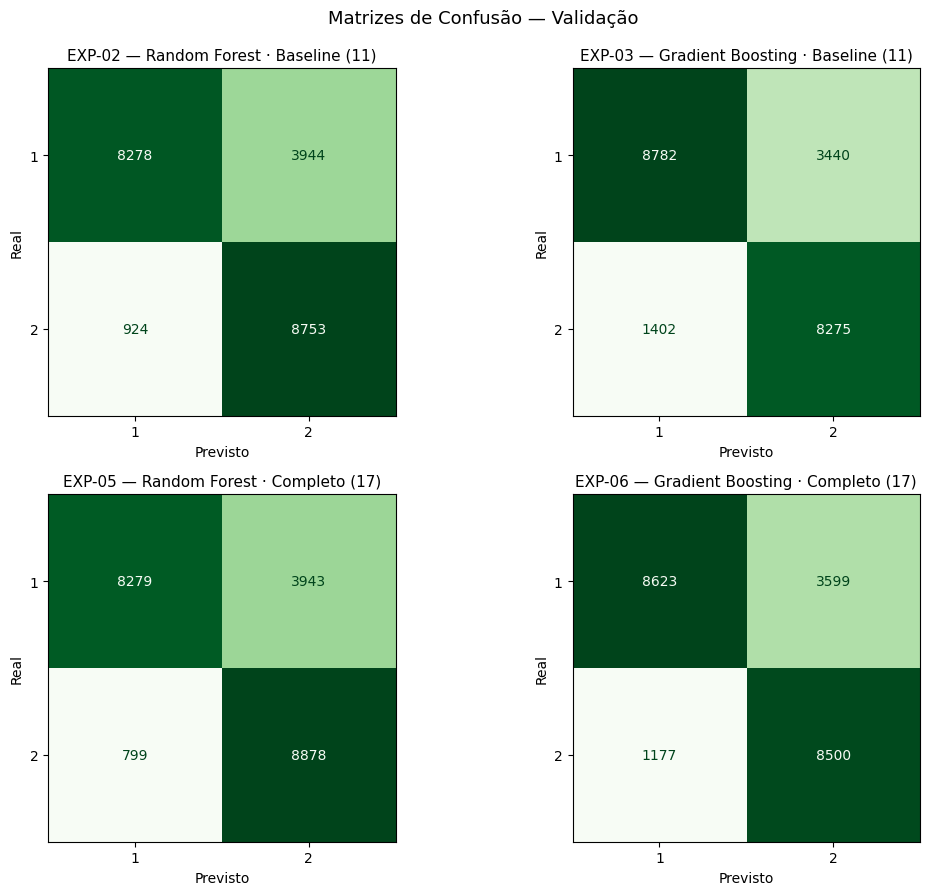

In [9]:
# Matrizes de confusão na validação
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, eid in zip(axes.ravel(), sorted(cms_val)):
    info = resumo.loc[eid]
    disp = ConfusionMatrixDisplay(cms_val[eid], display_labels=[1, 2])
    disp.plot(ax=ax, cmap="Greens", colorbar=False, values_format="d")
    ax.set_title(f"{eid} — {info['modelo']} · {info['conjunto']}", fontsize=11)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
for ax in axes.ravel()[len(cms_val):]:
    ax.axis("off")
fig.suptitle("Matrizes de Confusão — Validação", fontsize=13, y=0.99)
fig.tight_layout()
plt.show()

## 4. Conclusões

- A validação reproduz integralmente os notebooks 01 e 02 sobre `validation/*.json`,
  aplicando **parâmetros do treino** (imputador KNN re-ajustado só no treino, scaler do
  `data_preparation_metadata.json`) — **sem vazamento**.
- As métricas usam **a mesma convenção** do nb05 (`avaliar`): rótulos para
  acurácia/precisão/recall/F1/matriz de confusão e probabilidade para ROC AUC.
- `metricas_validacao.csv` guarda, por modelo, todas as métricas **e os hiperparâmetros
  usados** — material direto para o relatório explicativo.
- A comparação **teste × validação** (`comparacao_teste_validacao.csv`) quantifica a
  generalização de cada experimento.

> Modelos treinados em `MODO_RAPIDO = True`: resultados de demonstração, comparáveis
> entre si e ao teste do nb05, porém não oficiais da Tabela 1 do PDF.
